In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import torch

In [2]:
%env GEOMSTATS_BACKEND=pytorch
import geomstats.backend as gs
import geomstats.visualization as viz
from geomstats.geometry.base import ImmersedSet
from geomstats.geometry.diffeo import Diffeo
from geomstats.geometry.euclidean import Euclidean
from geomstats.geometry.pullback_metric import (
    PullbackDiffeoMetric,
    PullbackMetric,
)

env: GEOMSTATS_BACKEND=pytorch


In [3]:
class Paraboloid(ImmersedSet):

    def __init__(self, equip=True):
        super().__init__(dim=2, equip=equip)

    def immersion(self, point):
        u = point[..., 0]
        v = point[..., 1]
        return gs.stack(
            [
                u,
                v,
                u**2+v**2,
            ],
            axis=-1,
        )

    def _define_embedding_space(self):
        return Euclidean(dim=self.dim + 1)

In [4]:
my_manifold = Paraboloid(equip=False)

my_manifold.equip_with_metric(PullbackMetric)

In [5]:
my_manifold.metric.metric_matrix(gs.array([1.0,1.0]))

tensor([[5., 4.],
        [4., 5.]])

In [6]:
my_manifold.metric.inner_product(gs.array([1.0,1.0]),gs.array([1.0,0.0]),base_point=gs.array([1.0,1.0]))

tensor(9.)

In [7]:
my_manifold.metric.inner_coproduct(gs.array([1.0,1.0]),gs.array([1.0,0.0]),base_point=gs.array([1.0,1.0]))

tensor(0.1111)

In [8]:
# define the dataset
xs = [-1.0 + 1/32*i for i in range(32)]

dat = []
labels = []
for i in range(32):
    for j in range(32):
        dat.extend([[xs[i],xs[j]]])
        if xs[i]**2 + xs[j]**2 > np.sqrt(2)/2:
            col = 0
        else:
            col = 1
        labels.extend([col])

dat = gs.array(dat)
labels=gs.array(labels)

In [9]:
dat.shape

torch.Size([1024, 2])

In [10]:
labels.shape

torch.Size([1024])

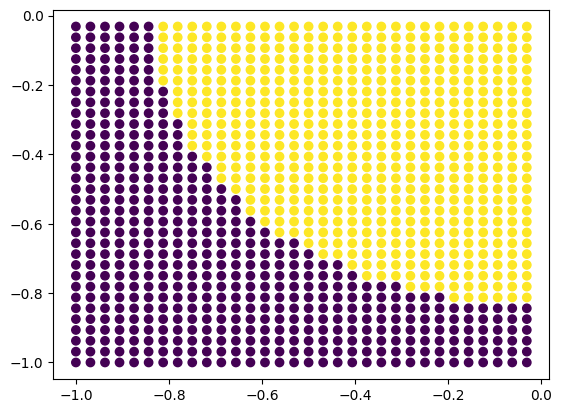

In [11]:
plt.scatter(dat.transpose(1,0)[0],dat.transpose(1,0)[1], c=labels)

In [12]:
def TangentVectorDistance(p, q, equipped_manifold=my_manifold):
    if not torch.is_tensor(p):
        p = torch.tensor(p, dtype=torch.float32)
    if not torch.is_tensor(q):
        q = torch.tensor(q, dtype=torch.float32)

    gradF = gs.array(2 * (q - p))
    proxy_dist = equipped_manifold.metric.inner_coproduct(gradF, gradF, base_point=p)
    return proxy_dist.item()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(dat, labels, test_size=0.5, random_state=0)

In [14]:
KNN = KNeighborsClassifier(metric=TangentVectorDistance, algorithm="ball_tree")

In [15]:
KNN.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'ball_tree'
,leaf_size,30
,p,2
,metric,<function Tan...x7ad207e8e020>
,metric_params,None
,n_jobs,None


In [16]:
t0 = time.time()
score = KNN.score(X_test,y_test)
t1 = time.time()
print(score)
print(t1-t0)

0.966796875
34.455331325531006


In [17]:
t2 = time.time()
test_dists = [TangentVectorDistance(X_test[0],X_train[i]) for i in range(X_train.shape[0])]
t3 = time.time()
print(t3-t2)

0.3839256763458252
